In [105]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.datasets import make_blobs 
from  sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler

In [106]:
X , y_true =make_blobs(n_samples=500 , centers =3 ,cluster_std =0.60, random_state=42)

In [107]:
df = pd.DataFrame(X, columns =["Feature_1" , "Feature_2"])

In [108]:
df.head()

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [109]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [110]:
inertia = []
K_range =range(1,11)

In [111]:
for k in K_range:
    kmeans = KMeans(n_clusters=k , random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [112]:
inertia

[1000.0000000000001,
 297.8954141051722,
 11.575484723104982,
 9.752067977356843,
 8.25717527244628,
 6.917577320416798,
 6.334755391595288,
 5.704177177901429,
 5.060234133532076,
 4.762361898130397]

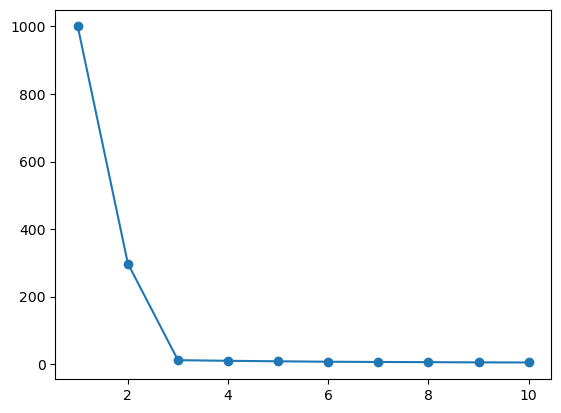

In [113]:
plt.plot(K_range , inertia ,marker='o')

In [114]:
kmeans_final=KMeans(n_clusters=3 , random_state=42)

In [115]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [116]:
df["cluster"]=cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

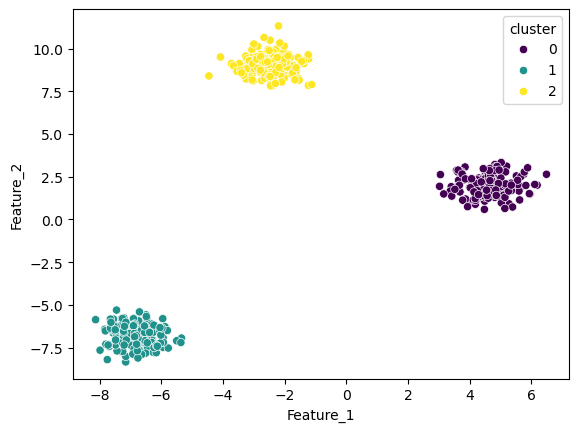

In [117]:
sns.scatterplot(x=df["Feature_1"],
               y=df["Feature_2"],
               hue =df['cluster'],
               palette='viridis')

# DBSCAn

In [118]:
from sklearn.datasets import make_moons

In [119]:
X,y_true = make_moons(n_samples=500 , noise=0.05,random_state=42)

In [120]:
from sklearn.cluster import KMeans ,DBSCAN 

In [121]:
df = pd.DataFrame(X,columns=["Feature_1" , "Feature_2"])



In [122]:
scaler =StandardScaler()
X_scaled = scaler.fit_transform(df)

In [123]:
kmeans =KMeans(n_clusters=2 ,random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [124]:
df["kmeans_cluster"] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

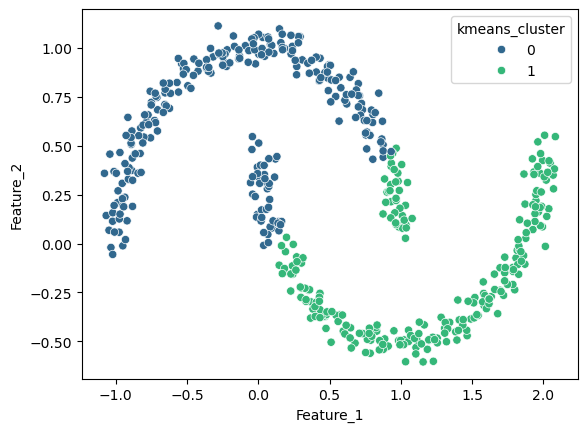

In [125]:
sns.scatterplot(x=df["Feature_1"],
               y=df["Feature_2"],
               hue =df['kmeans_cluster'],
               palette='viridis')

In [126]:
dbscan =DBSCAN(eps=0.3 , min_samples=5)
dbscan_labels=dbscan.fit_predict(X_scaled)

In [127]:
df["dbscan_cluster"] =dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

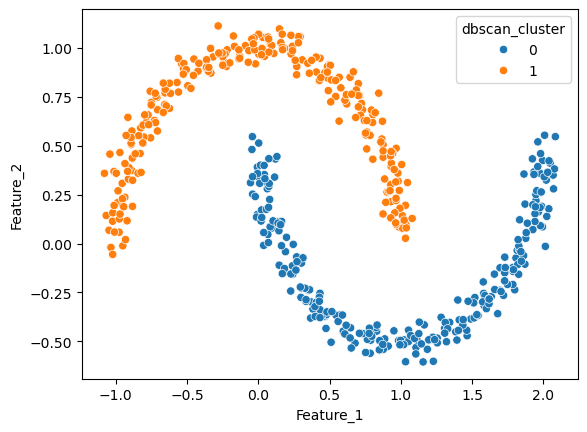

In [128]:
sns.scatterplot(x=df["Feature_1"],
               y=df["Feature_2"],
               hue =df['dbscan_cluster'],
               palette='tab10')